In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
fraud_df = pd.read_csv(
    "../data/raw/Fraud_Data.csv"
)

ip_df = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)

In [3]:
fraud_df['signup_time'] = pd.to_datetime(
    fraud_df['signup_time']
)

fraud_df['purchase_time'] = pd.to_datetime(
    fraud_df['purchase_time']
)

In [4]:
fraud_df['time_since_signup'] = (
    fraud_df['purchase_time']
    -
    fraud_df['signup_time']
).dt.total_seconds()

In [5]:
fraud_df['hour_of_day'] = (
    fraud_df['purchase_time']
    .dt.hour
)

In [6]:
fraud_df['day_of_week'] = (
    fraud_df['purchase_time']
    .dt.dayofweek
)

In [7]:
fraud_df['transaction_count'] = (
    fraud_df.groupby('user_id')
    ['user_id']
    .transform('count')
)

In [8]:
fraud_df['ip_address'] = (
    fraud_df['ip_address']
    .astype(int)
)

In [15]:
fraud_df = fraud_df.sort_values(
    'ip_address'
)

ip_df = ip_df.sort_values(
    'lower_bound_ip_address'
)

In [16]:
print(fraud_df['ip_address'].dtype)

print(ip_df['lower_bound_ip_address'].dtype)

print(ip_df['upper_bound_ip_address'].dtype)

int64
int64
int64


In [14]:
fraud_df['ip_address'] = fraud_df['ip_address'].astype('int64')

ip_df['lower_bound_ip_address'] = (
    ip_df['lower_bound_ip_address'].astype('int64')
)

ip_df['upper_bound_ip_address'] = (
    ip_df['upper_bound_ip_address'].astype('int64')
)

In [17]:
merged_df = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [18]:
merged_df = merged_df[
    merged_df['ip_address']
    <= merged_df['upper_bound_ip_address']
]

In [19]:
merged_df[['ip_address', 'country']].head()

,ip_address,country
634,16778864,Australia
635,16842045,Thailand
636,16843656,China
637,16938732,China
638,16971984,Thailand


In [20]:
merged_df['country'].isnull().sum()

np.int64(0)

In [21]:
fraud_df[['ip_address']].dtypes

ip_df[['lower_bound_ip_address',
       'upper_bound_ip_address']].dtypes

fraud_df.shape
ip_df.shape

(138846, 3)

In [23]:
merged_df.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

In [25]:
credit_df = pd.read_csv(
    "../data/raw/creditcard.csv"
)

credit_df.to_csv(
    "../data/processed/credit_processed.csv",
    index=False
)

In [26]:
merged_df.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'time_since_signup', 'hour_of_day', 'day_of_week', 'transaction_count',
       'lower_bound_ip_address', 'upper_bound_ip_address', 'country'],
      dtype='object')

## Transaction Velocity Features

In [27]:
merged_df = merged_df.sort_values(
    ['user_id', 'purchase_time']
)

In [28]:
merged_df['time_since_last_transaction'] = (
    merged_df.groupby('user_id')
             ['purchase_time']
             .diff()
             .dt.total_seconds()
)

In [29]:
merged_df['time_since_last_transaction'] = (
    merged_df['time_since_last_transaction']
    .fillna(-1)
)

In [30]:
merged_df[
    ['user_id',
     'purchase_time',
     'time_since_last_transaction']
].head()

,user_id,purchase_time,time_since_last_transaction
31545,2,2015-02-21 10:03:37,-1.0
97542,4,2015-09-26 21:32:16,-1.0
12873,8,2015-08-13 11:53:07,-1.0
104500,12,2015-03-04 20:56:37,-1.0
21011,16,2015-03-12 12:46:23,-1.0


In [31]:
country_fraud = (
    merged_df.groupby('country')['class']
    .mean()
    .sort_values(ascending=False)
)

In [32]:
country_fraud.head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

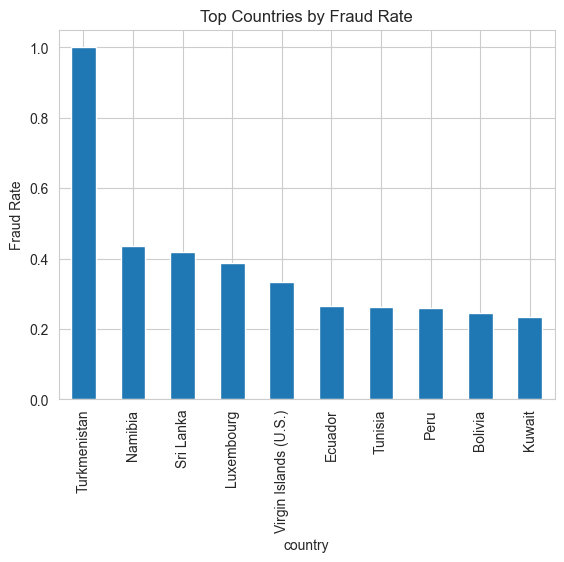

In [33]:
import matplotlib.pyplot as plt

country_fraud.head(10).plot(
    kind='bar'
)

plt.title(
    'Top Countries by Fraud Rate'
)

plt.ylabel('Fraud Rate')

plt.show()

Some countries, such as Turkmenistan, Namibia, Sri Lanka, exhibit substantially higher fraud rates than others, indicating that geographical information may provide useful predictive signals for fraud detection.

## One-Hot Encoding

In [34]:
categorical_cols = [
    'source',
    'browser',
    'sex',
    'country'
]

In [35]:
encoded_df = pd.get_dummies(
    merged_df,
    columns=categorical_cols,
    drop_first=True
)

In [36]:
encoded_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,time_since_signup,hour_of_day,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
31545,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,25,880217484,0,3564984.0,10,...,True,False,False,False,False,False,False,False,False,False
97542,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,38,2785906106,0,10039879.0,21,...,False,False,False,False,False,False,False,False,False,False
12873,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,25,356056736,0,6667201.0,11,...,True,False,False,False,False,False,False,False,False,False
104500,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,19,2985180352,0,4631485.0,20,...,False,False,False,False,False,False,False,False,False,False
21011,16,2015-02-03 13:48:23,2015-03-12 12:46:23,9,FROZWSSWOHZBE,32,578312545,0,3193080.0,12,...,True,False,False,False,False,False,False,False,False,False


## Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
numeric_cols = [
    'purchase_value',
    'age',
    'time_since_signup',
    'transaction_count',
    'time_since_last_transaction'
]

In [39]:
scaler = StandardScaler()

encoded_df[numeric_cols] = scaler.fit_transform(
    encoded_df[numeric_cols]
)

In [40]:
encoded_df[numeric_cols].head()

,purchase_value,age,time_since_signup,transaction_count,time_since_last_transaction
31545,0.931750,-0.943490,-0.435282,0.0,0.0
97542,0.222055,0.565460,1.633628,0.0,0.0
12873,0.549607,-0.943490,0.555963,0.0,0.0
104500,-0.105497,-1.639928,-0.094505,0.0,0.0
21011,-1.524887,-0.130978,-0.554116,0.0,0.0


In [41]:
encoded_df.to_csv(
    "../data/processed/fraud_processed.csv",
    index=False
)

In [42]:
encoded_df.shape

(129146, 202)